In [1]:
import numpy as np
import matplotlib.pyplot as plt

import raytracing as raytr

In [2]:
# define system parameters
NA = 1.3  # Objective NA
f_tl = 250  # Tube lens focal
f_obj = 3   # Objective focal (manufacturer tube lens focal / magnification)
BFP = 2 * f_obj * NA  # Objective back focal pupil

# sample refractive index
ns = 1.38

# Objective field of view
fov_obj = 0.320
# Sensor and pixel size
pixel_size = 0.0065
sensor_size = 2048 * pixel_size

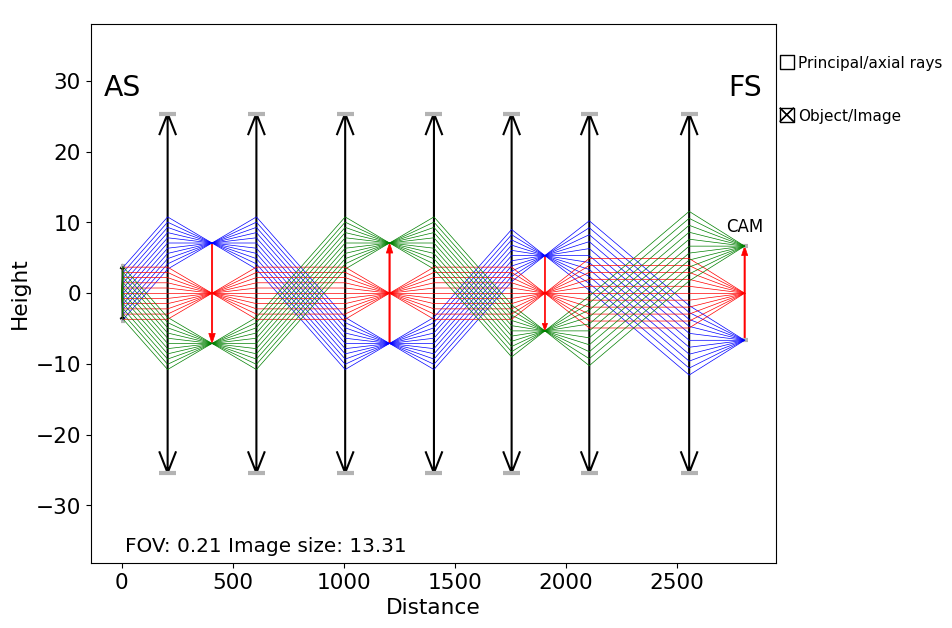

FOV: 0.21299079635371226
Magnification: Magnification(transverse=62.5, angular=0.016)


In [5]:
# define path
detection_path = raytr.ImagingPath()
detection_path.append(raytr.System2f(f_obj, BFP, label="OBJ"))
detection_path.append(raytr.System2f(200, 50.8, label="L1"))
detection_path.append(raytr.System2f(200, 50.8, label="L2"))
detection_path.append(raytr.System2f(200, 50.8, label="L3"))
detection_path.append(raytr.System2f(200, 50.8, label="L4"))
detection_path.append(raytr.System2f(150, 50.8, label="L5"))
detection_path.append(raytr.System2f(200, 50.8, label="L6"))
detection_path.append(raytr.System2f(f_tl, 50.8, label="TL"))
detection_path.append(raytr.Aperture(sensor_size, label="CAM"))

fov = detection_path.fieldOfView()

rays = raytr.ObjectRays(fov, np.arcsin(NA/ns), H=3, T=11)
detection_path.display(rays, removeBlocked=False)

print(f"FOV: {detection_path.fieldOfView()}")
print(f"Magnification: {detection_path.magnification()}")